# Country aspect ratio with `skar`

Pick a country, compute the aspect ratio of its tightest enclosing spherical
cone, and draw the outline with that bounding ellipse.

In [1]:
import geopandas as gpd
import skar

Load the countries with geopandas and grab one geometry. shapely renders it inline:

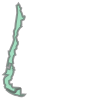

In [2]:
COUNTRY = 'Chile'

gdf = gpd.read_file('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson')
geom = gdf.loc[gdf['ADMIN'] == COUNTRY, 'geometry'].iloc[0]
geom

`skar.solve` takes the shapely geometry directly via `__geo_interface__` (its
rings become the point set) and returns a typed outcome. On a `Converged`,
`aspect_ratio` is the cross-section ratio (>= 1):

In [3]:
# Mainland Chile is extremely elongated (~38° of latitude), so its enclosing
# cone is slow to certify at the strict default tolerance — raise max_outer
# past the default 100 (the aspect ratio is stable well before then).
r = skar.solve(geom, max_outer=1000)
assert r.converged
print(f'{COUNTRY}: aspect ratio = {r.aspect_ratio:.3f}')

Chile: aspect ratio = 6.197


Draw it — one call. `skar.plot_cone` gnomonic-projects the outline at the cone
axis and overlays the cross-section ellipse, defaulting to north-up, metres, and
labelled axes:

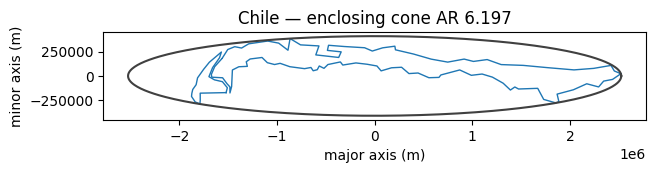

In [4]:
t = f'{COUNTRY} — enclosing cone AR {r.aspect_ratio:.3f}'
skar.plot_cone(r, geom, title=t);